In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy.optimize import fsolve
from pint import UnitRegistry
ureg = UnitRegistry()

# Old Desmos Model

# Original Data
data = pd.read_csv('NicaraguaData.csv')
x = data['Turbiedad (UNT)'].values.reshape(-1, 1)
y = data['Dosis (mg/L)'].values

# Constants
n = 1
C_DOM = 0
D = 0
q = 0.27
k_c = 1200
pi = math.pi

# Hydraulic flocculation model parameter
k = 0.66

# Height of the floc filter
h_ff = 1 * ureg.meter

# Desnity of a primary particle
rho_p = 1500 * ureg.milligram / (ureg.centimeter ** 3)

# Density of a coagulant nanoparticle
rho_c = 1138 * ureg.milligram / (ureg.centimeter ** 3)

# Radius of primary particle
r_p = 10 ** -6 * ureg.millimeter

# Radius of a coagulant nanoparticle
r_c = 90 * (10 ** -9) * ureg.millimeter

# Velocity gradient in flocculator
G = 10 * ureg.millimeter / ureg.second

# Hydraulic residence time of flocculator
theta_t = 15 * 60 * ureg.second

# Explicitly define x_data and y_data from the loaded DataFrame
x_data = data['Turbiedad (UNT)']  # Flatten to 1D array
y_data = data['Dosis (mg/L)'].values

# *****Formulas for Old Model*****
# Proportionality constant relating coagulant coverage to attachment efficiency
# I think rho_c and rho_p should actually be m_c and m_p
k_1 = rho_p / (rho_c * 4 * (((r_p + r_c) ** 2) / (r_c ** 2)))

# First term of k_pf; note slight modification: `k_1` (a.k.a. k') has been
# removed
k_pf_1 = 3 / (2 * pi * k * G * theta_t)
k_pf_2 = ((rho_p * pi) / 6) ** (2/3)
k_pf = k_pf_1 * k_pf_2

#min_C = np.minimum(((y_data - D) / x_data), 1)
#max_C = np.maximum(min_C, 0)
#C_flocculated = ((max_C / k_pf) + (x_data ** (-2/3))) ** (-3/2)

#min_p = np.minimum(((C_flocculated - 1) / (q * (x_data - 1))), 1)
#max_p = np.maximum(min_p, 0)
#P = max_p

#min_alpha = np.minimum((((y_data - D) / x_data) * ((1 - P) ** (2/3))), 1)
#max_alpha = np.maximum(min_alpha, 0)
#alpha = 1 - (1 - max_alpha) ** n

# Formulas for New Model

# Volume
V = (4/3) * pi * r_p ** 3

# Mass of a floc
m_floc = rho_p * V

# Concentration of flocs in clarifier
C_floc = rho_c

# Numerical floc density
N_floc = C_floc / m_floc

# Seperation distance between flocs
A = 1 / (N_floc ** (1/3))

# Volume fraction of flocs in the clarifier
phi_floc = V * C_floc / m_floc

def calc_C_flocculated(C_raw, C_coag):
    # Attachment efficiency (alpha) should be between 0 and 1
    attachment_efficiency = np.clip(k_1 * (C_coag - C_DOM)/C_raw, 0, 1)
    C_flocculated = (C_raw ** (-2/3) + coag_coverage/k_pf) ** (-3/2)
    return C_flocculated

# Takes in x and y values from the original data
def model_eq(C_coag, C_raw):
    C_flocculated = calc_C_flocculated(C_raw, C_coag)

    P = np.clip(((C_flocculated - 1) / (q * (x - 1))), 0, 1)

    min_alpha = np.minimum(((y - D) / x) * ((1 - P) ** (2/3)), 1)
    max_alpha = np.maximum(min_alpha, 0)
    alpha = 1 - (1 - max_alpha) ** n

    return C_flocculated * np.exp(-k_c * h_ff * alpha) - 1

# Solve each equation using x and y from the dataset
y_solved = []
for x in x_data:
    y_guess = 1
    y_sol = fsolve(model_eq, y_guess, args=(x,))
    y_solved.append(y_sol[0])

# New Model Graph (have to plot)
# y_new = x_data * (1-((alpha*pi)*((3*phi_floc/(4*pi))**(2/3))))**(h_ff/A)

plt.scatter(x_data, y_data)
plt.plot(x_data, y_solved, color='red')
plt.show()

NameError: name 'coag_coverage' is not defined

In [ ]:
# ???
k_c = 1200
# Height of the floc filter
h_ff = 1
# ???
q = 0.27
# Coagulant mass concentration to surface area coverage ratio?
k_1 = rho_p / (rho_c * 4 * ((r_p + r_c)^2 / r_c^2))
# Hydraulic flocculation model parameter
k=0.66
# Density of coagulant
rho_c = 1138
# Radius of a primary particle
r_p = 10^-6
# Radius of a coagulant nanoparticle
r_c = 90 * 10^-9
# Velocity gradient in flocculator
G = 10
# Hydraulic residence time of flocculator
theta_t = 15 * 60
# Combined hydraulic flocculation model parameter
k_pf = (3 / (2 * pi * k * k_1 * G * theta_t)) * ((rho_p * pi) / 6) ^ (2/3)

/tmp/ipykernel_14314/3366273690.py:159: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  y_sol = fsolve(model_eq, y_guess, args=(x,))
/tmp/ipykernel_14314/3366273690.py:159: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  y_sol = fsolve(model_eq, y_guess, args=(x,))


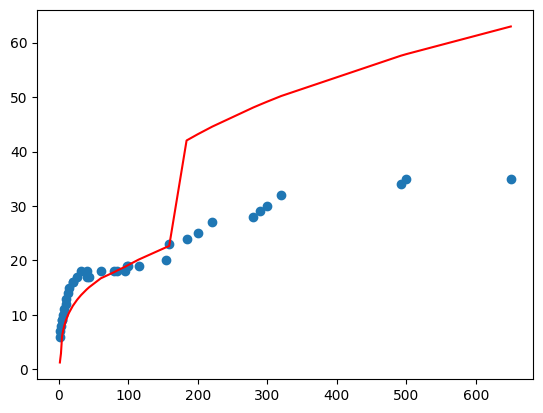

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
!pip install pint
from pint import UnitRegistry
from sklearn.linear_model import LinearRegression
from scipy.optimize import fsolve


# Old Desmos Model


# Constants


# ?
n = 1
D = 0
q = 0.27
k_c = 1200


pi = math.pi


# Hydraulic flocculation model parameter
k = 0.66


# Height of the floc filter
h_ff = 1


# Desnity of a primary particle
p_p = 1500


# Density of a coagulant nanoparticle
p_c = 1138


# Radius of primary particle
r_p = 10 ** -6


# Radius of a coagulant nanoparticle
r_c = 90 * (10 ** -9)


# Velocity gradient in flocculator
G = 10


# Hydraulic residence time of flocculator
theta_t = 15 * 60


# Explicitly define x_data and y_data from the loaded DataFrame
x_data = data['Turbiedad (UNT)']  # Flatten to 1D array
y_data = data['Dosis (mg/L)'].values


# Formulas for Old Model
k_1 = p_p / (p_c * 4 * (((r_p + r_c) ** 2) / (r_c ** 2)))


k_pf_1 = 3 / (2 * pi * k * k_1 * G * theta_t)
k_pf_2 = ((p_p * pi) / 6) ** (2/3)
k_pf = k_pf_1 * k_pf_2


#min_C = np.minimum(((y_data - D) / x_data), 1)
#max_C = np.maximum(min_C, 0)
#C_flocculated = ((max_C / k_pf) + (x_data ** (-2/3))) ** (-3/2)


#min_p = np.minimum(((C_flocculated - 1) / (q * (x_data - 1))), 1)
#max_p = np.maximum(min_p, 0)
#P = max_p


#min_alpha = np.minimum((((y_data - D) / x_data) * ((1 - P) ** (2/3))), 1)
#max_alpha = np.maximum(min_alpha, 0)
#alpha = 1 - (1 - max_alpha) ** n


# Formulas for New Model


# Volume
V = (4/3) * pi * r_p ** 3


# Mass of a floc
m_floc = p_p * V


# Concentration of flocs in clarifier
C_floc = p_c


# Numerical floc density
N_floc = C_floc / m_floc


# Seperation distance between flocs
A = 1 / (N_floc ** (1/3))


# Volume fraction of flocs in the clarifier
phi_floc = V * C_floc / m_floc


# Old Model Graph

# Implicitly solve for y using x
def model_alpha(y, x):
  P = 1 / np.exp(-k_c * h_ff * alpha)
  min_alpha = np.minimum((((y - D) / x) * ((1 - P) ** (2/3))), 1)
  max_alpha = np.maximum(min_alpha, 0)
  alpha = 1 - (1 - max_alpha) ** n

  all_alphas = []
  for x in x_data:
    model_alpha(y_data, x_data)
    return (1 - (1 - max_alpha) ** n) - alpha


alpha_data= [model_alpha(y, x)]





plt.scatter(x_data, y_data)
plt.show()

